In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/AI/FruitinAmazon.zip"
extract_path = "amazon_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ok")

ok


Classes: ['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


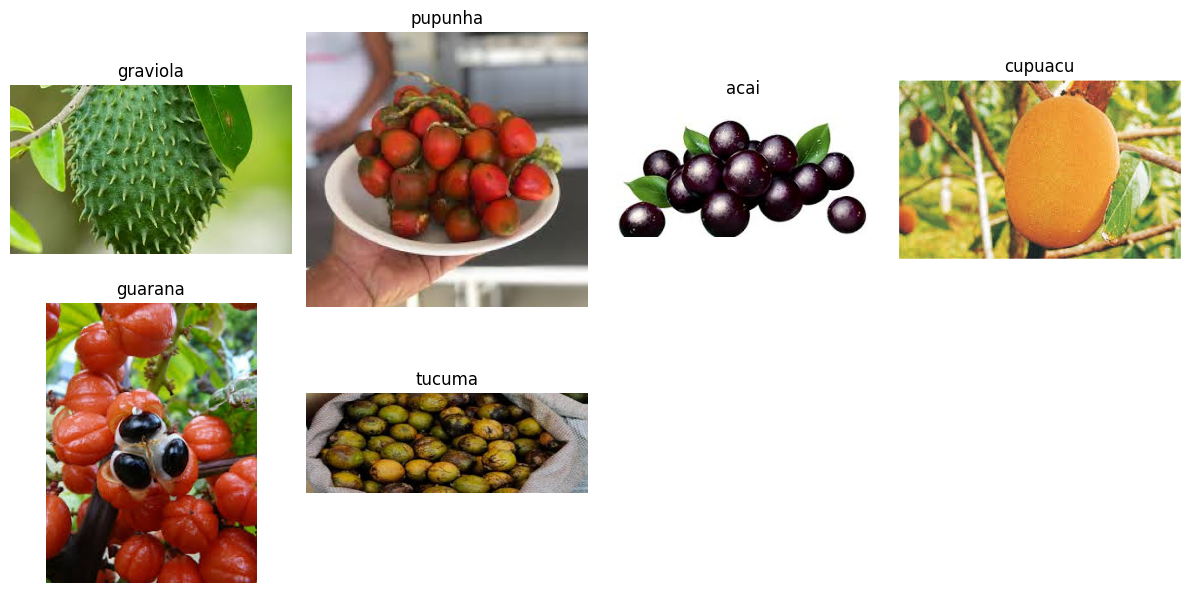

In [11]:

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "amazon_dataset/FruitinAmazon/train"

# Get class names
classes = os.listdir(train_dir)
print("Classes:", classes)

# Select one random image from each class
images = []
titles = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    images.append(Image.open(img_path))
    titles.append(cls)

# Plot in grid (2 rows)
plt.figure(figsize=(12, 6))
for i in range(len(images)):
    plt.subplot(2, (len(images)//2)+1, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalize layer
rescale = tf.keras.layers.Rescaling(1./255)

# Train dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [13]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Block 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.1655 - loss: 1.8977

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 576ms/step - accuracy: 0.1528 - loss: 1.9580 - val_accuracy: 0.0000e+00 - val_loss: 1.9261
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.2801 - loss: 1.6850

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.2778 - loss: 1.6942 - val_accuracy: 0.0000e+00 - val_loss: 1.8849
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.3466 - loss: 1.6746

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 842ms/step - accuracy: 0.3056 - loss: 1.6922 - val_accuracy: 0.1111 - val_loss: 1.8672
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.5307 - loss: 1.5060

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.5139 - loss: 1.5132 - val_accuracy: 0.2222 - val_loss: 1.7266
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.5087 - loss: 1.3466

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 484ms/step - accuracy: 0.9444 - loss: 0.2321 - val_accuracy: 0.8333 - val_loss: 0.4022
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 845ms/step - accuracy: 1.0000 - loss: 0.0926 - val_accuracy: 0.8333 - val_loss: 0.5734
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 846ms/step - accuracy: 0.9722 - loss: 0.1368 - val_accuracy: 0.8333 - val_loss: 0.5046
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 1.0000 - loss: 0.0377

3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 1.0000 - loss: 0.0362 - val_accuracy: 0.8889 - val_loss: 0.3244
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 1.0000 - loss: 0.0333

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 974ms/step - accuracy: 1.0000 - loss: 0.0336 - val_accuracy: 0.8889 - val_loss: 0.2806
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 1.0000 - loss: 0.0266

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 479ms/step - accuracy: 1.0000 - loss: 0.0267 - val_accuracy: 0.8333 - val_loss: 0.2638
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 1.0000 - loss: 0.0115

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.8889 - val_loss: 0.2541
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.8889 - val_loss: 0.3262
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 642ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.8333 - val_loss: 0.4198
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 703ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.8333 - val_loss: 0.4853
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 646ms/step - accuracy: 1.0000 - loss: 0.0046 - val_accuracy: 0.8333 - val_loss: 0.4681
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.8333 - val_loss: 0.4040
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8889 - val_loss: 0.3533
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8889 - val_lo

In [18]:
test_dir = "amazon_dataset/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7000 - loss: 0.8574
Test Accuracy: 0.699999988079071


In [19]:
# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step - accuracy: 0.7000 - loss: 0.8574


[0.8573726415634155, 0.699999988079071]

In [20]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
              precision    recall  f1-score   support

    graviola       0.44      0.80      0.57         5
     pupunha       0.67      0.80      0.73         5
        acai       1.00      0.80      0.89         5
     cupuacu       1.00      0.40      0.57         5
     guarana       0.83      1.00      0.91         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.77      0.70      0.69        30
weighted avg       0.77      0.70      0.69        30



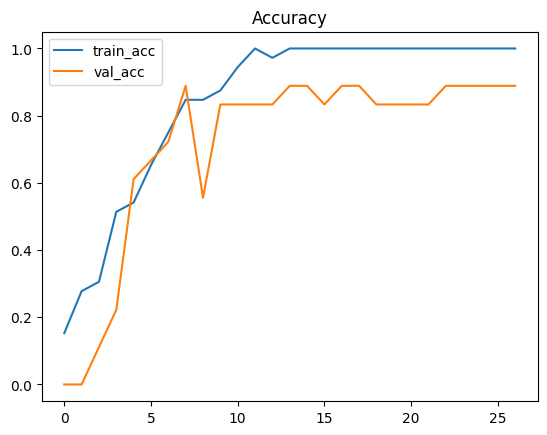

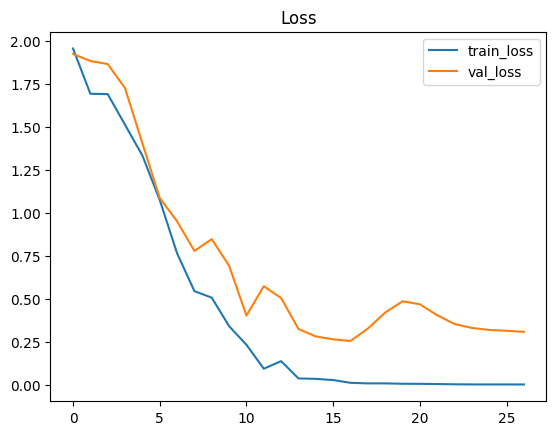

In [21]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()